# Data Augmentation — Gaussian Noise Regularisation
---

**Strategy:** Augmentation here is not used to generate new synthetic employers. Instead, Gaussian noise is applied to the continuous features of **real training records** within each cross-validation fold, introducing controlled perturbation as a regularisation strategy. This prevents the model from memorising exact training values and forces it to learn generalised patterns. SMOTE is handled separately to address class imbalance.

**Input:** `features.csv` from `01_eda.ipynb`  
**Output:** `augmentation.py` — a reusable module to import inside each CV fold

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 2. Load Feature Matrix

In [8]:
features = pd.read_csv(r"D:\MSc. Data Science(UG)\Semester 2\Deep Learning & Neural Networks\Mini Project\features.csv")

print("Shape:", features.shape)
print("\nColumns:", list(features.columns))
print("\nClass balance:")
print(features['DEFAULT_LABEL'].value_counts())
features.head()

Shape: (1000, 11)

Columns: ['EMPLOYER ID', 'TOTAL_ARREARS', 'MAX_CONSECUTIVE_MISSED', 'AVG_CONTRIBUTION_RATIO', 'SANCTION_SEVERITY', 'PAYMENT_RATE', 'AMOUNT_CV', 'AMOUNT_TREND', 'EMPLOYER_TENURE', 'AVG_PAYMENT_DELAY', 'DEFAULT_LABEL']

Class balance:
DEFAULT_LABEL
0    747
1    253
Name: count, dtype: int64


,EMPLOYER ID,TOTAL_ARREARS,MAX_CONSECUTIVE_MISSED,AVG_CONTRIBUTION_RATIO,SANCTION_SEVERITY,PAYMENT_RATE,AMOUNT_CV,AMOUNT_TREND,EMPLOYER_TENURE,AVG_PAYMENT_DELAY,DEFAULT_LABEL
0,XXXXX0010_20190102,122179.860000,0,1.000000,2.0,1.000000,0.625885,-7.812883,6.995209,220.354167,0
1,XXXXX0011_20070122,-495630.249312,0,1.000000,2.0,1.000000,0.218855,10910.506218,18.940452,11.979167,0
2,XXXXX0011_20180102,41715.000000,0,0.993056,2.0,0.979167,0.400094,9.602556,7.994524,72.319149,1
3,XXXXX0025_20180103,631.530000,0,1.000000,2.0,1.000000,0.310405,5.000202,7.991786,20.062500,0
4,XXXXX0027_20220105,2214.000000,0,1.000000,0.0,1.000000,0.091871,0.422058,3.986311,35.145833,0


In [9]:
# Separate identifier, features, and target
ID_COL     = 'EMPLOYER ID'
TARGET_COL = 'DEFAULT_LABEL'

# Continuous features — Gaussian noise will be applied to these
CONTINUOUS_COLS = [
    'TOTAL_ARREARS', 'MAX_CONSECUTIVE_MISSED', 'AVG_CONTRIBUTION_RATIO',
    'PAYMENT_RATE', 'AMOUNT_CV', 'AMOUNT_TREND',
    'EMPLOYER_TENURE', 'AVG_PAYMENT_DELAY'
]

# Ordinal feature — noise not applied, value is discrete (0, 1, 2)
ORDINAL_COLS = ['SANCTION_SEVERITY']

FEATURE_COLS = CONTINUOUS_COLS + ORDINAL_COLS

X = features[FEATURE_COLS].copy()
y = features[TARGET_COL].copy()

print("Continuous features:", CONTINUOUS_COLS)
print("Ordinal features:", ORDINAL_COLS)

Continuous features: ['TOTAL_ARREARS', 'MAX_CONSECUTIVE_MISSED', 'AVG_CONTRIBUTION_RATIO', 'PAYMENT_RATE', 'AMOUNT_CV', 'AMOUNT_TREND', 'EMPLOYER_TENURE', 'AVG_PAYMENT_DELAY']
Ordinal features: ['SANCTION_SEVERITY']


## 3. Standardise Features
Noise is defined relative to each feature's standard deviation after standardisation. The scaler must be fit on training data only — M3 re-fits inside each CV fold. Here we fit on the full dataset purely for augmentation development and validation.

In [10]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=FEATURE_COLS
)

print("Scaled feature statistics:")
X_scaled.describe().round(3)

Scaled feature statistics:


,TOTAL_ARREARS,MAX_CONSECUTIVE_MISSED,AVG_CONTRIBUTION_RATIO,PAYMENT_RATE,AMOUNT_CV,AMOUNT_TREND,EMPLOYER_TENURE,AVG_PAYMENT_DELAY,SANCTION_SEVERITY
count,1000.000,1000.0,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,-0.000,0.0,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000
std,1.001,0.0,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-29.117,0.0,-7.309,-6.808,-1.422,-1.019,-1.442,-5.925,-1.220
25%,-0.001,0.0,0.252,0.172,-0.666,-0.141,-0.750,-0.525,-1.220
50%,0.006,0.0,0.330,0.384,-0.208,-0.135,-0.368,-0.386,0.820
75%,0.043,0.0,0.330,0.384,0.381,-0.110,0.543,0.149,0.820
max,1.711,0.0,0.330,0.384,4.448,19.204,2.779,5.142,0.820


## 4. Gaussian Noise Augmentation
Gaussian noise is added **only to continuous features**. The ordinal `SANCTION_SEVERITY` is left unchanged since adding fractional noise to a 3-level categorical encoding is not meaningful.

In [11]:
def add_gaussian_noise(X, continuous_cols, sigma=0.05, rng=None):
    """Add Gaussian noise only to continuous features.
    
    Parameters
    ----------
    X              : pd.DataFrame — standardised feature matrix
    continuous_cols: list         — columns to apply noise to
    sigma          : float        — noise std relative to standardised scale
    rng            : np.Generator — random number generator
    
    Returns
    -------
    pd.DataFrame with noise applied to continuous_cols only
    """
    rng = rng or np.random.default_rng()
    X_noisy = X.copy()
    noise = rng.normal(loc=0.0, scale=sigma, size=(len(X), len(continuous_cols)))
    X_noisy[continuous_cols] = X_noisy[continuous_cols].values + noise
    return X_noisy


# Demo: one noisy copy of the dataset
X_noisy = add_gaussian_noise(X_scaled, CONTINUOUS_COLS, sigma=0.05, rng=rng)

# Confirm ordinal feature is unchanged
assert (X_noisy['SANCTION_SEVERITY'].values == X_scaled['SANCTION_SEVERITY'].values).all(), \
    "SANCTION_SEVERITY should be unchanged"

print("Noise applied successfully.")
print(f"SANCTION_SEVERITY unchanged: ✓")
print(f"\nNoise magnitude check (should be ~0.05):")
print((X_noisy[CONTINUOUS_COLS] - X_scaled[CONTINUOUS_COLS]).std().round(4))

Noise applied successfully.
SANCTION_SEVERITY unchanged: ✓

Noise magnitude check (should be ~0.05):
TOTAL_ARREARS             0.0495
MAX_CONSECUTIVE_MISSED    0.0494
AVG_CONTRIBUTION_RATIO    0.0499
PAYMENT_RATE              0.0508
AMOUNT_CV                 0.0488
AMOUNT_TREND              0.0513
EMPLOYER_TENURE           0.0499
AVG_PAYMENT_DELAY         0.0514
dtype: float64


## 5. Choosing the Noise Level (sigma)
Too much noise distorts the data; too little has no regularisation effect. We test sigma values of 0.01, 0.05, and 0.10 and select based on how well each preserves the original feature distributions.

In [12]:
sigmas = [0.01, 0.05, 0.10]
ks_results = []

for sigma in sigmas:
    X_test = add_gaussian_noise(X_scaled, CONTINUOUS_COLS, sigma=sigma,
                                rng=np.random.default_rng(RANDOM_STATE))
    for col in CONTINUOUS_COLS:
        stat, pval = stats.ks_2samp(X_scaled[col], X_test[col])
        ks_results.append({'Sigma': sigma, 'Feature': col,
                           'KS Statistic': round(stat, 4), 'p-value': round(pval, 4)})

ks_df = pd.DataFrame(ks_results)
print("Mean KS statistic per sigma (lower = more similar to original):")
print(ks_df.groupby('Sigma')['KS Statistic'].mean().round(4))

Mean KS statistic per sigma (lower = more similar to original):
Sigma
0.01    0.1852
0.05    0.2200
0.10    0.2444
Name: KS Statistic, dtype: float64


C:\Users\justi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


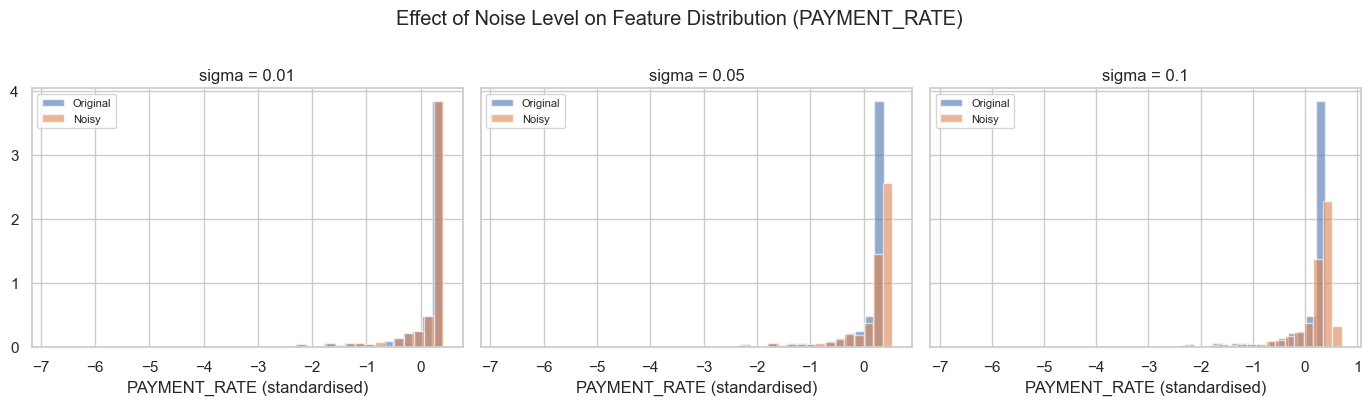


Selected sigma = 0.05 — sufficient perturbation without distorting the distribution.


In [13]:
# Visual comparison of sigma levels for one representative feature
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, sigma in zip(axes, sigmas):
    X_test = add_gaussian_noise(X_scaled, CONTINUOUS_COLS, sigma=sigma,
                                rng=np.random.default_rng(RANDOM_STATE))
    ax.hist(X_scaled['PAYMENT_RATE'], bins=40, alpha=0.6, label='Original', density=True)
    ax.hist(X_test['PAYMENT_RATE'],   bins=40, alpha=0.6, label='Noisy',    density=True)
    ax.set_title(f'sigma = {sigma}')
    ax.set_xlabel('PAYMENT_RATE (standardised)')
    ax.legend(fontsize=8)

plt.suptitle('Effect of Noise Level on Feature Distribution (PAYMENT_RATE)', y=1.01)
plt.tight_layout()
plt.show()

print("\nSelected sigma = 0.05 — sufficient perturbation without distorting the distribution.")

## 6. SMOTE for Class Imbalance
SMOTE is applied separately from noise augmentation. It addresses the 75/25 class split by interpolating between real minority-class (defaulting) employer records. Applied **only on training folds** — never on validation or test data.

In [14]:
smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X_scaled, y)

print("Before SMOTE:")
print(y.value_counts().to_string())
print("\nAfter SMOTE:")
print(pd.Series(y_smote).value_counts().to_string())

Before SMOTE:
DEFAULT_LABEL
0    747
1    253

After SMOTE:
DEFAULT_LABEL
0    747
1    747


## 7. Full Augmentation Pipeline
The correct order for M3 inside each CV fold:
1. Fit `StandardScaler` on training fold, transform both train and validation
2. Apply SMOTE to balance the training fold
3. Apply Gaussian noise to the SMOTE-balanced training fold
4. Train TabNet on the augmented fold; evaluate on the **unaugmented** validation fold

In [15]:
def augment_training_fold(X_train, y_train,
                          continuous_cols,
                          sigma=0.05,
                          random_state=42):
    """Full augmentation pipeline for one training fold.

    Steps
    -----
    1. SMOTE  — balance classes by interpolating real minority records
    2. Gaussian noise — perturb continuous features for regularisation

    Parameters
    ----------
    X_train        : pd.DataFrame — scaled training features
    y_train        : pd.Series    — training labels
    continuous_cols: list         — columns to apply noise to
    sigma          : float        — noise std (default 0.05)
    random_state   : int

    Returns
    -------
    X_aug, y_aug — augmented training data

    IMPORTANT: Never call this on validation or test data.
    """
    rng = np.random.default_rng(random_state)

    # Step 1: SMOTE
    sm = SMOTE(random_state=random_state)
    X_bal, y_bal = sm.fit_resample(X_train, y_train)
    X_bal = pd.DataFrame(X_bal, columns=X_train.columns)
    y_bal = pd.Series(y_bal, name=y_train.name)

    # Step 2: Gaussian noise on continuous features only
    X_aug = add_gaussian_noise(X_bal, continuous_cols, sigma=sigma, rng=rng)
    y_aug = y_bal.copy().reset_index(drop=True)

    return X_aug.reset_index(drop=True), y_aug


# Demonstration
X_aug, y_aug = augment_training_fold(
    X_scaled, y,
    continuous_cols=CONTINUOUS_COLS,
    sigma=0.05
)

print(f"Original :  {len(X_scaled):>5} records  |  Class balance: {y.value_counts().to_dict()}")
print(f"Augmented:  {len(X_aug):>5} records  |  Class balance: {y_aug.value_counts().to_dict()}")

Original :   1000 records  |  Class balance: {0: 747, 1: 253}
Augmented:   1494 records  |  Class balance: {0: 747, 1: 747}


## 8. Validation — Real vs Augmented Distributions

In [16]:
# KS test per continuous feature
ks_final = []
for col in CONTINUOUS_COLS:
    stat, pval = stats.ks_2samp(X_scaled[col], X_aug[col])
    ks_final.append({
        'Feature'      : col,
        'KS Statistic' : round(stat, 4),
        'p-value'      : round(pval, 4),
        'Similar?'     : 'Yes' if pval > 0.05 else 'No'
    })

print("KS test — real vs augmented (sigma=0.05):")
pd.DataFrame(ks_final)

KS test — real vs augmented (sigma=0.05):


,Feature,KS Statistic,p-value,Similar?
0,TOTAL_ARREARS,0.1927,0.0000,No
1,MAX_CONSECUTIVE_MISSED,0.5141,0.0000,No
2,AVG_CONTRIBUTION_RATIO,0.4466,0.0000,No
3,PAYMENT_RATE,0.4674,0.0000,No
4,AMOUNT_CV,0.1050,0.0000,No
5,AMOUNT_TREND,0.2721,0.0000,No
6,EMPLOYER_TENURE,0.0478,0.1238,Yes
7,AVG_PAYMENT_DELAY,0.1304,0.0000,No


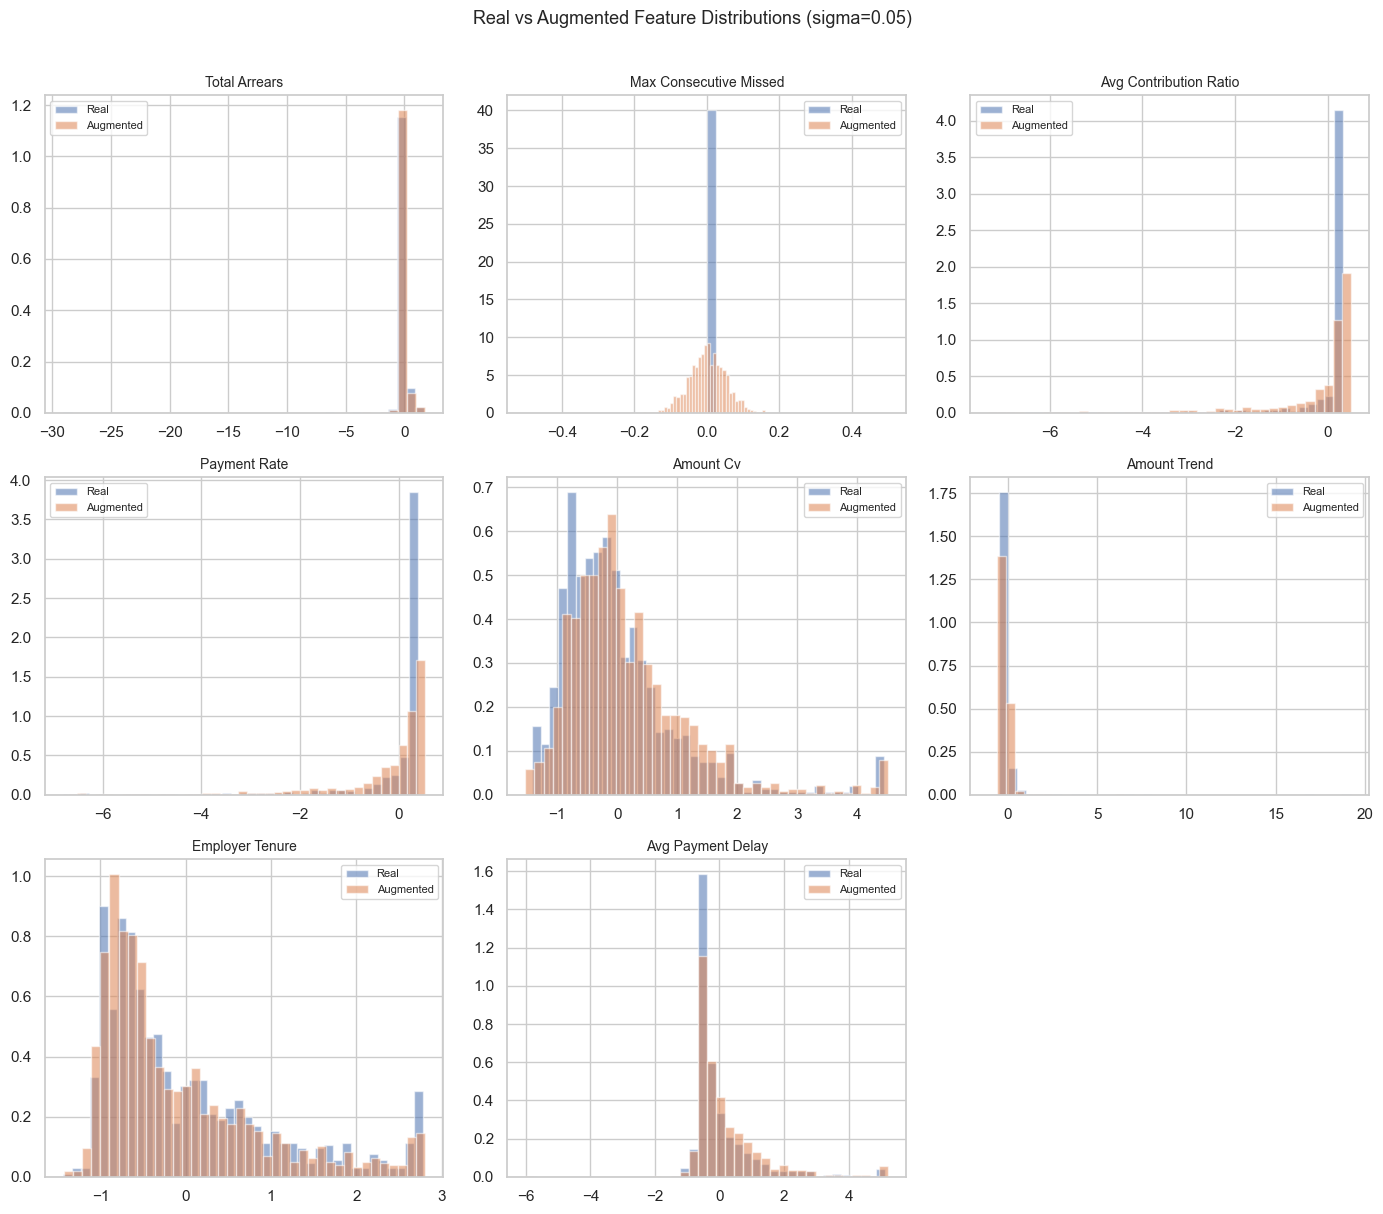

In [17]:
# Distribution overlays for all continuous features
n_cols = len(CONTINUOUS_COLS)
n_rows = int(np.ceil(n_cols / 3))
fig, axes = plt.subplots(n_rows, 3, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_COLS):
    axes[i].hist(X_scaled[col], bins=40, alpha=0.55, label='Real',      density=True)
    axes[i].hist(X_aug[col],    bins=40, alpha=0.55, label='Augmented', density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].legend(fontsize=8)

for j in range(n_cols, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Real vs Augmented Feature Distributions (sigma=0.05)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 9. Export Augmentation Module for M3

In [18]:
module_code = '''
"""augmentation.py
Gaussian noise regularisation pipeline — Member 2.

Usage in 03_modelling.ipynb (inside each CV fold):
    from augmentation import augment_training_fold, CONTINUOUS_COLS
    X_aug, y_aug = augment_training_fold(X_train_scaled, y_train, CONTINUOUS_COLS)

Rules:
    - Call ONLY on training folds
    - NEVER augment validation or test folds
    - Fit StandardScaler on training fold only before calling this
"""
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE

# Continuous features to apply noise to
CONTINUOUS_COLS = [
    'TOTAL_ARREARS', 'MAX_CONSECUTIVE_MISSED', 'AVG_CONTRIBUTION_RATIO',
    'PAYMENT_RATE', 'AMOUNT_CV', 'AMOUNT_TREND',
    'EMPLOYER_TENURE', 'AVG_PAYMENT_DELAY'
]


def add_gaussian_noise(X, continuous_cols, sigma=0.05, rng=None):
    """Add Gaussian noise to continuous features only."""
    rng = rng or np.random.default_rng()
    X_noisy = X.copy()
    noise = rng.normal(loc=0.0, scale=sigma, size=(len(X), len(continuous_cols)))
    X_noisy[continuous_cols] = X_noisy[continuous_cols].values + noise
    return X_noisy


def augment_training_fold(X_train, y_train,
                          continuous_cols=None,
                          sigma=0.05,
                          random_state=42):
    """SMOTE + Gaussian noise augmentation for one training fold."""
    continuous_cols = continuous_cols or CONTINUOUS_COLS
    rng = np.random.default_rng(random_state)

    # Step 1: SMOTE — balance classes
    sm = SMOTE(random_state=random_state)
    X_bal, y_bal = sm.fit_resample(X_train, y_train)
    X_bal = pd.DataFrame(X_bal, columns=X_train.columns)
    y_bal = pd.Series(y_bal, name=y_train.name)

    # Step 2: Gaussian noise — regularise continuous features
    X_aug = add_gaussian_noise(X_bal, continuous_cols, sigma=sigma, rng=rng)
    y_aug = y_bal.reset_index(drop=True)

    return X_aug.reset_index(drop=True), y_aug
'''

export_path = "D:/MSc. Data Science(UG)/Semester 2/Deep Learning & Neural Networks/Mini Project/augmentation.py"
with open(export_path, 'w') as f:
    f.write(module_code)

print(f"Saved augmentation.py to:\n{export_path}")
print("\nM3 imports with:")
print("  from augmentation import augment_training_fold, CONTINUOUS_COLS")

Saved augmentation.py to:
D:/MSc. Data Science(UG)/Semester 2/Deep Learning & Neural Networks/Mini Project/augmentation.py

M3 imports with:
  from augmentation import augment_training_fold, CONTINUOUS_COLS


## 10. Handoff Notes for M3

1. Place `augmentation.py` in the same folder as `03_modelling.ipynb`
2. Import at the top of the modelling notebook:
   ```python
   from augmentation import augment_training_fold, CONTINUOUS_COLS
   ```
3. Inside each of the 5 CV folds, follow this order:
   - Fit `StandardScaler` on the **training fold only**
   - Transform both train and validation with the fitted scaler
   - Call `augment_training_fold(X_train_scaled, y_train, CONTINUOUS_COLS)` on the training fold
   - Train TabNet on the augmented output
   - Evaluate on the **original unaugmented** validation fold
4. Default sigma is `0.05` — validated in Section 5 of this notebook
5. `SANCTION_SEVERITY` is intentionally excluded from noise — it is ordinal and should remain discrete